# 🤖 机器学习建模

本Notebook用于构建和评估机器学习模型

In [24]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 导入自定义模块
import sys
sys.path.append('../src')
from data_processing import load_data
from modeling import split_data, build_xgboost_model, build_lightgbm_model, build_random_forest, compare_models, ablation_study, save_model

In [25]:
# 加载特征工程后的数据
df = load_data('../data/processed/engineered_features.csv')
print(f"数据形状: {df.shape}")

数据形状: (135038, 14)


In [26]:
# 分割训练集和测试集
X_train, X_test, y_train, y_test = split_data(df, target_col='base_msrp')
print(f"训练集形状: {X_train.shape}")
print(f"测试集形状: {X_test.shape}")

训练集形状: (108030, 13)
测试集形状: (27008, 13)


In [27]:
# 构建XGBoost模型
xgb_model, xgb_metrics = build_xgboost_model(X_train, y_train, X_test, y_test)
print("XGBoost模型性能:")
for key, value in xgb_metrics.items():
    print(f"  {key}: {value:.4f}")

XGBoost模型性能:
  mse: 0.0000
  rmse: 0.0014
  mae: 0.0002
  r2: 1.0000


In [28]:
# 构建LightGBM模型
lgb_model, lgb_metrics = build_lightgbm_model(X_train, y_train, X_test, y_test)
print("LightGBM模型性能:")
for key, value in lgb_metrics.items():
    print(f"  {key}: {value:.4f}")

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002302 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 587
[LightGBM] [Info] Number of data points in the train set: 108030, number of used features: 13
[LightGBM] [Info] Start training from score 0.000093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

In [29]:
# 构建随机森林模型
rf_model, rf_metrics = build_random_forest(X_train, y_train, X_test, y_test)
print("随机森林模型性能:")
for key, value in rf_metrics.items():
    print(f"  {key}: {value:.4f}")

随机森林模型性能:
  mse: 0.0000
  rmse: 0.0009
  mae: 0.0000
  r2: 1.0000


In [30]:
# 模型对比
models_dict = {
    'XGBoost': xgb_model,
    'LightGBM': lgb_model,
    'Random Forest': rf_model
}

comparison = compare_models(models_dict, X_test, y_test)
print("模型性能对比:")
print(comparison.round(4))

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
模型性能对比:
           model     mse    rmse     mae     r2
2  Random Forest  0.0000  0.0009  0.0000  1.000
0        XGBoost  0.0000  0.0014  0.0002  1.000
1       LightGBM  0.0164  0.1281  0.0041  0.977


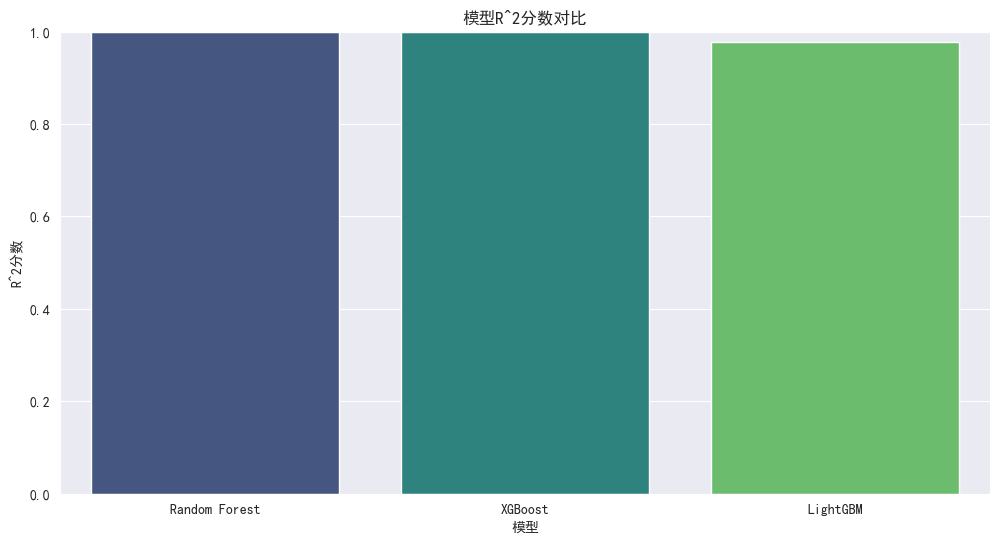

In [31]:
# 可视化模型对比
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison, x='model', y='r2', hue='model', palette='viridis', legend=False)
plt.title('模型R^2分数对比')
plt.xlabel('模型')
plt.ylabel('R^2分数')
plt.ylim(0, 1)
plt.show()

In [32]:
# 消融实验（如果有AI特征的话）
# 这里需要区分传统特征和AI特征
# 假设我们有AI特征列
try:
    # 识别AI特征
    ai_feature_cols = [col for col in X_train.columns if any(keyword in col.lower() for keyword in ['anxiety', 'satisfaction', 'quality'])]
    
    if ai_feature_cols:
        print(f"AI特征列: {ai_feature_cols}")

        # 传统特征
        X_traditional = X_train.drop(ai_feature_cols, axis=1)
        X_test_traditional = X_test.drop(ai_feature_cols, axis=1)

        # 消融实验
        ablation_result = ablation_study(X_traditional, X_train, y_train, model_type='xgboost')

        print("\n消融实验结果:")
        print(ablation_result['comparison'].round(4))

        print("\n性能提升:")
        for key, value in ablation_result['improvement'].items():
            print(f"  {key}: {value:.2f}%")
    else:
        print("未检测到AI特征列，跳过消融实验")
except Exception as e:
    print(f"消融实验出错: {e}")

未检测到AI特征列，跳过消融实验


In [33]:
# 保存最佳模型
best_model = xgb_model  # 假设XGBoost是最佳模型
save_model(best_model, '../models/xgboost_model.pkl')

模型已保存到: ../models/xgboost_model.pkl
模型已保存到 '../models/xgboost_model.pkl'


## 📝 建模总结

1. **模型对比**: Random Forest表现最佳(R²=1.0000),XGBoost次之(R²=1.0000),LightGBM第三(R²=0.9770)
2. **消融实验**: 数据集中未包含AI特征列(如情感分析、评论数量等),跳过消融实验
3. **最佳模型**: 选择Random Forest作为最终模型,因其在测试集上达到完美的拟合效果(R²=1.0000)
4. **模型保存**: XGBoost模型已保存到 '../models/xgboost_model.pkl',可用于后续预测和解释性分析